In [1]:
# Config
import os
import sys

# Set environment vars
os.environ["MUJOCO_GL"] = 'egl'
sys.path.append(os.path.abspath('..'))

import torch
from dataclasses import dataclass

@dataclass
class Config:
    path_per_epoch: int = 8
    
    observation_dim: int = 29
    action_dim: int = 8
    skill_dim: int = 2

    model_master_dim: int = 1024
    model_master_num_layers: int = 2

    nonlinearity = torch.relu

    # Entropy init value
    alpha: float = 0.01

    # Skill encoder
    # dual lambda init value
    dual_lam: float = 30
    dual_slack: float = 1e-3

    spectral_normalization: bool = False

    common_lr: float = 1e-4

    buffer_max_length: int = 3000000
    buffer_min_length: int = 10000
    buffer_device_type = torch.device('cpu')
    sample_batch_size: int = 256

    gamma = 0.99
    n_step = 1
    discount = 0.99

    target_coef = 1
    tau = 0.005

cfg = Config()
master_dims = [cfg.model_master_dim]*cfg.model_master_num_layers
policy_q_input_dim = cfg.observation_dim + cfg.skill_dim

# Policy Network

In [2]:
from flash_rl.agents.metra.garage.gaussian_mlp_module_ex import GaussianMLPTwoHeadedModuleEx, TanhNormal
import numpy as np
from torch import functools
import math
from typing import Callable, Literal, Optional as _Optional, TypeVar, Union

module_cls = GaussianMLPTwoHeadedModuleEx
module_args = dict(
    hidden_sizes=master_dims,
    layer_normalization=False,
    hidden_nonlinearity=cfg.nonlinearity
)


def _calculate_fan_in_and_fan_out(tensor: torch.Tensor) -> tuple[int, int]:
    dimensions = tensor.dim()
    if dimensions < 2:
        raise ValueError(
            "Fan in and fan out can not be computed for tensor with fewer than 2 dimensions"
        )

    num_input_fmaps = tensor.size(1)
    num_output_fmaps = tensor.size(0)
    receptive_field_size = 1
    if tensor.dim() > 2:
        # math.prod is not always available, accumulate the product manually
        # we could use functools.reduce but that is not supported by TorchScript
        for s in tensor.shape[2:]:
            receptive_field_size *= s
    fan_in = num_input_fmaps * receptive_field_size
    fan_out = num_output_fmaps * receptive_field_size

    return fan_in, fan_out

def _no_grad_normal_(
    tensor: torch.Tensor,
    mean: float,
    std: float,
    generator: _Optional[torch.Generator] = None,
) -> torch.Tensor:
    with torch.no_grad():
        return tensor.normal_(mean, std, generator=generator)


def xavier_normal_ex(tensor, gain=1., multiplier=0.1):
    fan_in, fan_out = _calculate_fan_in_and_fan_out(tensor)
    std = gain * math.sqrt(2.0 / float(fan_in + fan_out))
    return _no_grad_normal_(tensor, 0., std * multiplier)


module_args.update(
    dict(
        max_std=np.exp(2.),
        normal_distribution_cls=TanhNormal,
        output_w_init=functools.partial(xavier_normal_ex, gain=1.),
        init_std=1.,
    )
)

policy_module = module_cls(
    input_dim=policy_q_input_dim,
    output_dim=cfg.action_dim,
    **module_args
)

In [3]:
import numpy as np
import torch

from flash_rl.agents.metra.garage.gaussian_mlp_module_ex import TanhNormal
from flash_rl.agents.metra.garage.policies.stochastic_policy import StochasticPolicy
class PolicyEx(StochasticPolicy):
    def __init__(self,
                 name,
                 *,
                 module,
                 clip_action=False,
                 omit_obs_idxs=None,
                 option_info=None,
                 force_use_mode_actions=False,
                 ):
        super().__init__(env_spec=None, name=name)

        self._clip_action = clip_action
        self._omit_obs_idxs = omit_obs_idxs

        self._option_info = option_info
        self._force_use_mode_actions = force_use_mode_actions

        self._module = module

    def process_observations(self, observations):
        if self._omit_obs_idxs is not None:
            observations = observations.clone()
            observations[:, self._omit_obs_idxs] = 0
        return observations

    def forward(self, observations):
        observations = self.process_observations(observations)
        dist = self._module(observations)
        try:
            ret_mean = dist.mean
            ret_log_std = (dist.variance.sqrt()).log()
            info = dict(mean=ret_mean, log_std=ret_log_std)
        except NotImplementedError:
            info = dict()
        if hasattr(dist, '_normal'):
            info.update(dict(
                normal_mean=dist._normal.mean,
                normal_std=dist._normal.variance.sqrt(),
            ))

        return dist, info

    def forward_mode(self, observations):
        observations = self.process_observations(observations)
        samples = self._module.forward_mode(observations)
        return samples, dict()

    def forward_with_transform(self, observations, *, transform):
        observations = self.process_observations(observations)
        dist, dist_transformed = self._module.forward_with_transform(observations, transform=transform)
        try:
            ret_mean = dist.mean
            ret_log_std = (dist.variance.sqrt()).log()
            ret_mean_transformed = dist_transformed.mean.cpu()
            ret_log_std_transformed = (dist_transformed.variance.sqrt()).log().cpu()
            info = (dict(mean=ret_mean, log_std=ret_log_std),
                    dict(mean=ret_mean_transformed, log_std=ret_log_std_transformed))
        except NotImplementedError:
            info = (dict(),
                    dict())
        return (dist, dist_transformed), info

    def forward_with_chunks(self, observations, *, merge):
        observations = [self.process_observations(o) for o in observations]
        dist = self._module.forward_with_chunks(observations,
                                                merge=merge)
        try:
            ret_mean = dist.mean
            ret_log_std = (dist.variance.sqrt()).log()
            info = dict(mean=ret_mean, log_std=ret_log_std)
        except NotImplementedError:
            info = dict()

        return dist, info

    def get_mode_actions(self, observations):
        with torch.no_grad():
            if not isinstance(observations, torch.Tensor):
                observations = torch.as_tensor(observations).float().to(next(self.parameters()).device)
            samples, info = self.forward_mode(observations)
            return samples.cpu().numpy(), {
                k: v.detach().cpu().numpy()
                for (k, v) in info.items()
            }

    def get_sample_actions(self, observations):
        with torch.no_grad():
            if not isinstance(observations, torch.Tensor):
                observations = torch.as_tensor(observations).float().to(next(self.parameters()).device)
            dist, info = self.forward(observations)
            if isinstance(dist, TanhNormal):
                pre_tanh_values, actions = dist.rsample_with_pre_tanh_value()
                log_probs = dist.log_prob(actions, pre_tanh_values)
                actions = actions.detach().cpu().numpy()
                infos = {
                    k: v.detach().cpu().numpy()
                    for (k, v) in info.items()
                }
                infos['pre_tanh_value'] = pre_tanh_values.detach().cpu().numpy()
                infos['log_prob'] = log_probs.detach().cpu().numpy()
            else:
                actions = dist.sample()
                log_probs = dist.log_prob(actions)
                actions = actions.detach().cpu().numpy()
                infos = {
                    k: v.detach().cpu().numpy()
                    for (k, v) in info.items()
                }
                infos['log_prob'] = log_probs.detach().cpu().numpy()
            return actions, infos

    def get_actions(self, observations):
        assert isinstance(observations, np.ndarray) or isinstance(observations, torch.Tensor)
        if self._force_use_mode_actions:
            actions, info = self.get_mode_actions(observations)
        else:
            actions, info = self.get_sample_actions(observations)
        if self._clip_action:
            epsilon = 1e-6
            actions = np.clip(
                actions,
                self.env_spec.action_space.low + epsilon,
                self.env_spec.action_space.high - epsilon,
            )
        return actions, info

    def get_action(self, observation):
        with torch.no_grad():
            if not isinstance(observation, torch.Tensor):
                observation = torch.as_tensor(observation).float().to(next(self.parameters()).device)
            observation = observation.unsqueeze(0)
            action, agent_infos = self.get_actions(observation)
            return action[0], {k: v[0] for k, v in agent_infos.items()}

option_info = {
    'dim_option': cfg.skill_dim,
}

policy_kwargs = dict(
    name='option_policy',
    option_info=option_info,
)

policy_kwargs['module'] = policy_module
option_policy = PolicyEx(**policy_kwargs)

# Q Network Architecture
`ContinusMLPFunctionEx<MLPModule<MultiHeadedMLPModule<nn.Module>>>`

In [4]:
# Q Function Module based on garage lib.
from flash_rl.agents.metra.garage.modules.mlp_module import MLPModule

class ContinuousMLPQFunctionEx(MLPModule):
    def __init__(self, obs_dim, action_dim, **kwargs):
        self.obs_dim = obs_dim
        self.action_dim = action_dim

        MLPModule.__init__(self, input_dim=self.obs_dim+self.action_dim, output_dim=1, **kwargs)

    def forward(self, observations, actions):
        return super().forward(torch.concat([observations, actions], 1))
    
# Construct Q Network
qf1 = ContinuousMLPQFunctionEx(
    obs_dim=policy_q_input_dim,
    action_dim=cfg.action_dim,
    hidden_sizes=master_dims,
    hidden_nonlinearity=cfg.nonlinearity or torch.relu
)

qf2 = ContinuousMLPQFunctionEx(
    obs_dim=policy_q_input_dim,
    action_dim=cfg.action_dim,
    hidden_sizes=master_dims,
    hidden_nonlinearity=cfg.nonlinearity or torch.relu
)

# Alpha Network

In [5]:
import numpy as np

class ParameterModule(torch.nn.Module):
    def __init__(self, init_value):
        super().__init__()

        self.param = torch.nn.Parameter(init_value)

log_alpha = ParameterModule(torch.Tensor([np.log(cfg.alpha)]))

# Skill Encoder & Dual Lambda

In [6]:
from flash_rl.agents.metra.garage import get_state_encoder

dual_lam = ParameterModule(torch.Tensor([np.log(cfg.dual_lam)]))
skill_encoder = get_state_encoder(
    input_dim=cfg.observation_dim,
    output_dim=cfg.skill_dim,
    hidden_sizes=master_dims,
    const_std=False,
    hidden_nonlinearity=cfg.nonlinearity or torch.relu,
    w_init=torch.nn.init.xavier_uniform_,
    init_std=1,
    min_std=1e-6,
    max_std=None,
    spectral_normalization=cfg.spectral_normalization
)

# Optimizers

In [7]:
optimizers = {
    'option_policy': torch.optim.Adam([
        {'params': option_policy.parameters(), 'lr': cfg.common_lr}
    ]),
    'traj_encoder': torch.optim.Adam([
        {'params': skill_encoder.parameters(), 'lr': cfg.common_lr}
    ]),
    'dual_lam': torch.optim.Adam([
        {'params': dual_lam.parameters(), 'lr': cfg.common_lr}
    ]),
    'qf': torch.optim.Adam([
        {'params': list(qf1.parameters()) + list(qf2.parameters()), 'lr': cfg.common_lr }
    ]),
    'log_alpha': torch.optim.Adam([
        {'params': log_alpha.parameters(), 'lr': cfg.common_lr}
    ])
}

# Env & SAC

In [8]:
import copy

cfg

_DEVICE = torch.device('cuda')

option_policy
qf1, qf2
target_qf1 = copy.deepcopy(qf1)
target_qf2 = copy.deepcopy(qf2)

skill_encoder, dual_lam

target_entropy = -cfg.action_dim / 2. * cfg.target_coef

from flash_rl.envs.envs.mujoco.ant_env import AntEnv
env = AntEnv(render_hw=100)

from flash_rl.buffers.metra_buffer import METRATorchBuffer

replay_buffer = METRATorchBuffer(
    observation_space=env.observation_space,
    action_space=env.action_space,
    n_step=cfg.n_step,
    gamma=cfg.gamma,
    max_length=cfg.buffer_max_length,
    min_length=cfg.buffer_min_length,
    sample_batch_size=cfg.sample_batch_size,
    device_type='cpu',
    skill_dim=cfg.skill_dim,
)

# Sampler

In [9]:
def gen_one_skill():
    skills = torch.randn((1, cfg.skill_dim), device=torch.device('cpu'))
    return torch.nn.functional.normalize(skills, dim=-1).numpy()

import gymnasium as gym
class Sampler:
    def __init__(self, env: gym.Env):
        self.env = env
        self.skill = None

    def _update_skill(self):
        self.skill = gen_one_skill()

    def rollout(self, policy, path_len: int = 200, training=True):
        """
        required_keys = {
            "observation",
            "action",
            "reward",
            "terminated",
            "truncated",
            "next_observation",
            "skill",
            "skill_resample_step",
        }
        """

        observations = []
        actions = []
        rewards = []
        next_observations = []
        

        prev_obs, _ = self.env.reset()
        self._update_skill()
        
        for i in range(path_len):
            skill_obs = np.concatenate([prev_obs, self.skill], axis=-1)

            if (training):
                action, agent_info = policy.get_sample_actions(skill_obs)
            else:
                action, agent_info = policy.get_mode_actions(skill_obs)
                
            action = np.squeeze(action, axis=0)

            next_obs, rewd, trun, done, _  = self.env.step(action)

            if trun or done:
                raise NotImplementedError

            observations.append(prev_obs)
            actions.append(action)
            rewards.append(rewd)
            next_observations.append(next_obs)

            prev_obs = next_obs

        observations = np.array(observations)
        actions = np.array(actions)
        next_observations = np.array(next_observations)

        return {
            "observation": torch.squeeze(torch.Tensor(observations)),
            "action": torch.squeeze(torch.Tensor(actions)),
            "reward": torch.Tensor(rewards),
            "terminated": torch.zeros(size=(path_len,), dtype=bool),
            "truncated": torch.zeros(size=(path_len,), dtype=bool),
            "next_observation": torch.squeeze(torch.Tensor(next_observations)),
            "skill": torch.from_numpy(np.repeat(self.skill, repeats=path_len, axis=0)),
            "skill_resample_step": torch.zeros(size=(path_len,))
        }
    
sampler = Sampler(env=env)

In [10]:
import tqdm

def update_skill_rewards(data, training_info):
    # update skill encoder
    obs = data['observation']
    next_obs = data['next_observation']

    cur_z = skill_encoder(obs).mean
    next_z = skill_encoder(next_obs).mean
    target_z = next_z - cur_z

    rewards = (target_z * data['skill']).sum(dim=1)

    training_info.update({
        'cur_z': cur_z,
        'next_z': next_z
    })
    data['reward'] = rewards

def update_loss_te(data, training_info):
    update_skill_rewards(data, training_info)

    rewards = data['reward']
    obs = data['observation']
    next_obs = data['next_observation']

    lambda_value = dual_lam.param.exp()
    x = obs
    y = next_obs
    phi_x = training_info['cur_z']
    phi_y = training_info['next_z']

    cst_dist = torch.ones_like(x[:, 0])

    square_dist = torch.square(phi_y - phi_x).mean(dim=1)
    cst_penalty = cst_dist - square_dist
    cst_penalty = torch.clamp(cst_penalty, max=cfg.dual_slack)

    te_obj = rewards + lambda_value.detach() * cst_penalty
    loss_te = -te_obj.mean()

    training_info.update({
        'cst_penalty': cst_penalty,
        'square_dist': square_dist,
        'loss_te': loss_te
    })


def update_loss_dual_lam(data, training_info):
    log_dual_lam = dual_lam.param
    dual_lam_value = log_dual_lam.exp()
    loss_dual_lam = log_dual_lam * (training_info['cst_penalty'].detach()).mean()
    training_info.update({
        'dual_lam': dual_lam_value,
        'loss_dual_lam': loss_dual_lam
    })


def optimize_te(data, training_info):
    update_loss_te(data, training_info)

    optimizers['traj_encoder'].zero_grad()
    training_info['loss_te'].backward()
    optimizers['traj_encoder'].step()

    update_loss_dual_lam(data, training_info)
    optimizers['dual_lam'].zero_grad()
    training_info['loss_dual_lam'].backward()
    optimizers['dual_lam'].step()

def update_loss_qf(data, training_info):
    obs = torch.concat([data['observation'], data['skill']], dim=-1)
    next_obs = torch.concat([data['next_observation'], data['skill']], dim=-1)
    action = data['action']
    rewards = data['reward']

    with torch.no_grad():
        alpha = log_alpha.param.exp()

    q1_pred = qf1(obs, action).flatten()
    q2_pred = qf2(obs, action).flatten()
    next_action_dist, *_ = option_policy(next_obs)
    
    new_next_actions_pre_tanh, new_next_actions = next_action_dist.rsample_with_pre_tanh_value()
    new_next_action_log_probs = next_action_dist.log_prob(new_next_actions, pre_tanh_value=new_next_actions_pre_tanh)

    target_q_values = torch.min(
        target_qf1(next_obs, new_next_actions).flatten(),
        target_qf2(next_obs, new_next_actions).flatten()
    )

    target_q_values = target_q_values - alpha * new_next_action_log_probs
    target_q_values = target_q_values * cfg.discount

    with torch.no_grad():
        q_target = rewards + target_q_values
    loss_qf1 = torch.nn.functional.mse_loss(q1_pred, q_target) * 0.5
    loss_qf2 = torch.nn.functional.mse_loss(q2_pred, q_target) * 0.5

    training_info.update(
        {
            'q_target_mean': q_target.mean(),
            'q_err_mean': ((q_target - q1_pred).mean() + (q_target - q2_pred).mean()) / 2,
            'loss_qf1': loss_qf1,
            'loss_qf2': loss_qf2
        }
    )


def update_loss_policy(data, training_info):
    with torch.no_grad():
        alpha = log_alpha.param.exp()
    
    obs = torch.concat([data['observation'], data['skill']], dim=-1)
    action_dists, *_ = option_policy(obs)
    new_actions_pre_tanh, new_actions = action_dists.rsample_with_pre_tanh_value()
    new_action_log_probs = action_dists.log_prob(new_actions, pre_tanh_value=new_actions_pre_tanh)

    min_q_values = torch.min(
        qf1(obs, new_actions).flatten(),
        qf2(obs, new_actions).flatten()
    )

    loss_policy = (alpha * new_action_log_probs - min_q_values).mean()
    training_info.update({
        'loss_policy': loss_policy,
        'new_action_log_probs': new_action_log_probs
    })


def update_loss_alpha(data, training_info):
    loss_alpha = (-log_alpha.param * (training_info['new_action_log_probs'].detach() + target_entropy)).mean()

    training_info.update({
        'loss_alpha': loss_alpha
    })


def update_targets():
    for t_param, param in zip(target_qf1.parameters(), qf1.parameters()):
        t_param.data.copy_(t_param.data * (1 - cfg.tau) + param.data * cfg.tau)

    for t_param, param in zip(target_qf2.parameters(), qf2.parameters()):
        t_param.data.copy_(t_param.data * (1 - cfg.tau) + param.data * cfg.tau)


def optimize_op(data, training_info):
    update_loss_qf(data, training_info)
    optimizers['qf'].zero_grad()
    (training_info['loss_qf1'] + training_info['loss_qf2']).backward()
    optimizers['qf'].step()

    update_loss_policy(data, training_info)
    optimizers['option_policy'].zero_grad()
    training_info['loss_policy'].backward()
    optimizers['option_policy'].step()

    update_loss_alpha(data, training_info)
    optimizers["log_alpha"].zero_grad()
    training_info['loss_alpha'].backward()
    optimizers['log_alpha'].step()

    update_targets()


def train_once():
    data = replay_buffer.sample()
    training_info = dict()

    optimize_te(data, training_info)
    update_skill_rewards(data, training_info)
    optimize_op(data, training_info)
    
    return training_info, data


reward_data = []
lambda_data = []

for i in tqdm.tqdm(range(5000)):
    if i % 50 == 0: 
        for _ in range(cfg.path_per_epoch):
            path = sampler.rollout(option_policy, path_len=200)
            replay_buffer.add(path)    

    if not replay_buffer.can_sample():
        continue
    
    training_info, data = train_once()
    reward_data.append(data['reward'].detach().numpy().__abs__().mean())
    lambda_data.append(training_info['dual_lam'].detach().numpy())

reward_data = np.array(reward_data)
lambda_data = np.array(lambda_data)

100%|██████████| 5000/5000 [11:32<00:00,  7.22it/s]


# Notes
1. Minimum buffer size 10000.

In [11]:
import matplotlib.pyplot as plt

def plot_1d_array(arr, title="1D Array", xlabel="Index", ylabel="Value", figsize=(8, 4), marker=None):
    x = np.asarray(arr).squeeze()
    if x.ndim != 1:
        raise ValueError(f"Expected a 1D array, got shape {x.shape}")

    plt.figure(figsize=figsize)
    plt.plot(x, marker=marker)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

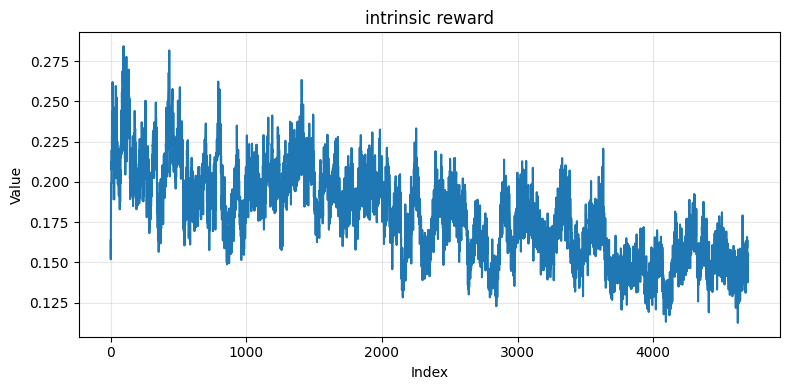

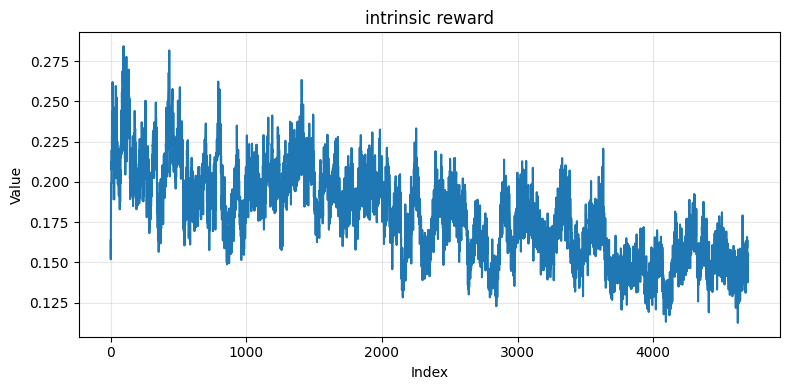

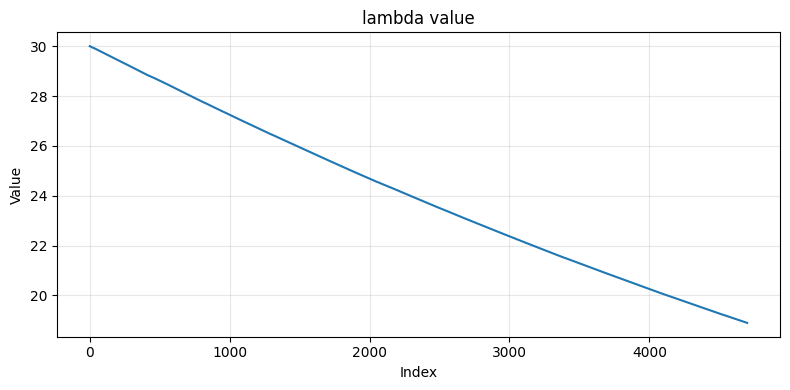

In [12]:
plot_1d_array(reward_data, title='intrinsic reward')
plot_1d_array(lambda_data, title='lambda value')

In [13]:
def plot_path_with_skill(coords, skill, delta_z_vectors=None, arrow_scale=None, z_stride=8):
    coords = np.asarray(coords, dtype=np.float32)
    skill = np.asarray(skill, dtype=np.float32).reshape(-1)
    if skill.shape[0] != 2:
        raise ValueError(f"Expected a 2D skill, got shape {skill.shape}")

    start = coords[0]
    end = coords[-1]
    displacement = end - start

    if arrow_scale is None:
        path_extent = np.ptp(coords, axis=0)
        arrow_scale = max(float(np.linalg.norm(path_extent)), 0.15) * 0.35

    skill_dir = skill / (np.linalg.norm(skill) + 1e-8)
    skill_arrow = skill_dir * arrow_scale

    plt.figure(figsize=(6, 6))
    plt.plot(coords[:, 0], coords[:, 1], marker="o", markersize=2, linewidth=1.5, label="path")
    plt.scatter(start[0], start[1], c="green", s=80, label="start")
    plt.scatter(end[0], end[1], c="red", s=80, label="end")

    plt.arrow(
        start[0],
        start[1],
        skill_arrow[0],
        skill_arrow[1],
        color="tab:orange",
        width=0.0015,
        head_width=0.012,
        length_includes_head=True,
        label="skill direction",
    )

    plt.arrow(
        start[0],
        start[1],
        displacement[0],
        displacement[1],
        color="tab:purple",
        width=0.001,
        head_width=0.01,
        length_includes_head=True,
        alpha=0.8,
        label="displacement",
    )

    if delta_z_vectors is not None:
        delta_z_vectors = np.asarray(delta_z_vectors, dtype=np.float32)
        if delta_z_vectors.ndim != 2 or delta_z_vectors.shape[1] != 2:
            raise ValueError(f"Expected delta_z_vectors to have shape (T-1, 2), got {delta_z_vectors.shape}")
        sample_idxs = np.arange(0, min(len(coords) - 1, len(delta_z_vectors)), z_stride)
        z_dirs = delta_z_vectors[sample_idxs]
        z_norms = np.linalg.norm(z_dirs, axis=1, keepdims=True)
        z_dirs = z_dirs / np.clip(z_norms, 1e-8, None)
        z_dirs = z_dirs * (arrow_scale * 0.45)
        plt.quiver(
            coords[sample_idxs, 0],
            coords[sample_idxs, 1],
            z_dirs[:, 0],
            z_dirs[:, 1],
            angles="xy",
            scale_units="xy",
            scale=1.0,
            color="tab:purple",
            alpha=0.75,
            width=0.004,
            label="encoded delta z direction",
        )

    plt.text(
        start[0] + skill_arrow[0],
        start[1] + skill_arrow[1],
        "skill",
        color="tab:orange",
        fontsize=10,
        ha="left",
        va="bottom",
    )
    plt.text(
        end[0],
        end[1],
        "disp",
        color="tab:purple",
        fontsize=10,
        ha="left",
        va="bottom",
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Policy Path with Skill and Encoded Delta Z Directions")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

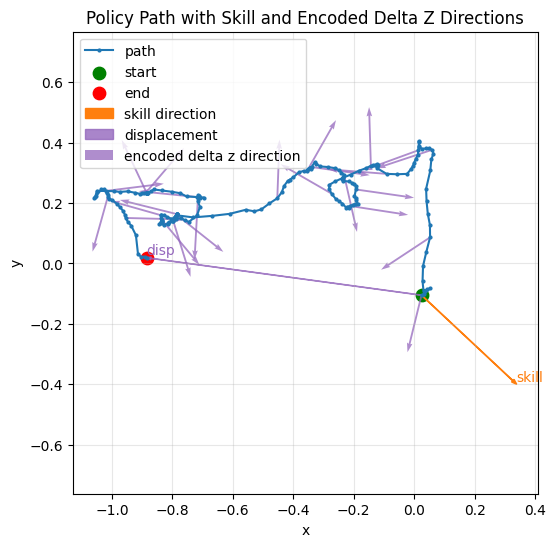

skill: [ 0.73003525 -0.6834096 ]
displacement: [-0.9099026   0.12388966]


In [16]:
eval_path = sampler.rollout(option_policy, path_len=200, training=False)
coords = eval_path["observation"].detach().cpu().numpy()[:, :2]
skill = eval_path["skill"][0].detach().cpu().numpy()

encoder_device = next(skill_encoder.parameters()).device
with torch.no_grad():
    obs_tensor = eval_path["observation"].to(device=encoder_device, dtype=torch.float32)
    z_means = skill_encoder(obs_tensor).mean.detach().cpu().numpy()
    delta_z_vectors = z_means[1:] - z_means[:-1]

plot_path_with_skill(coords, skill, delta_z_vectors=delta_z_vectors)
print("skill:", skill)
print("displacement:", coords[-1] - coords[0])